# HYCOM vs GLORYS — Fram Strait

Follow-up to [transects_transports.ipynb](transects_transports.ipynb), which introduces the transport framework on the native HYCOM grid. Here we compare HYCOM TP2 output against GLORYS across Fram Strait using two methods.

| | **Method 1** — native grids | **Method 2** — hybrid |
|---|---|---|
| **HYCOM** | native HYCOM grid | regridded vertically only |
| **GLORYS** | native GLORYS grid | regridded horizontally only |
| **Shared horizontal grid** | — | HYCOM curvilinear (y, x) |
| **Shared vertical grid** | — | GLORYS depth |
| **Sections** | ✔ | ✔ |
| **Section diff plots** | — | ✔ |
| **Transport** | ✔ | ✔ |
| **Transport diff plots** | ✔ | ✔ |

A third option — regridding HYCOM onto the full GLORYS grid — is omitted: at 0.083° GLORYS resolves far finer than TP2, so the regrid is expensive and adds little information. As shown below, Method 1 is the preferred choice for transport; Method 2 is useful when co-registered section plots and valid difference maps are needed.

### How transport is computed in each case

**GLORYS (both methods)** uses T-point projection. GLORYS stores `uo`/`vo` as geographic east/north components at T-cell centres. `resolve(glorys_data, lat_var=..., lon_var=...)` snaps the section to the nearest T-cells; `transport(..., z_dim="depth")` projects `uo`/`vo` onto the local section bearing and integrates over depth.

**HYCOM (both methods)** uses face-exact C-grid integration. `u-vel.`/`v-vel.` live at staggered U/V faces on the Arakawa C-grid and are by construction normal to those faces — no rotation or interpolation to T-points is needed. `resolve(grid)` identifies the faces the section crosses via the hemisphere-mask algorithm ([MSCPROGS](https://github.com/nansencenter/NERSC-HYCOM-CICE/tree/develop/hycom/MSCPROGS)), and `transport()` sums the signed face-normal fluxes over all faces and layers. In Method 2, only the vertical dimension is regridded onto GLORYS depth levels; the horizontal C-grid staggering is fully preserved. `transport()` derives layer thicknesses from the depth-level spacing and integrates exactly as in Method 1.


In [1]:
import numpy as np
import xarray as xr
import xhycom
import matplotlib.pyplot as plt

In [2]:
GRID_PATH   = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/regional.grid"
BATHY_PATH  = "/cluster/home/nlo043/NERSC-HYCOM-CICE/TP2a0.10/topo/depth_TP2a0.10_01"
DATA_PATH   = "/nird/datalake/NS9481K/shuang/TP2_output/expt_02.8/"
GLORYS_PATH = "/nird/datapeak/NS9481K/MERCATOR_DATA/PHY/2020/MERCATOR-PHY-24-2020-*.nc"

### Helper functions

In [3]:
def plot_hycom_vs_glorys(hycom_sec, glorys_sec, *, show_diff=False, title=None):
    ncols = 3 if show_diff else 2
    fig, axes = plt.subplots(2, ncols, figsize=(8 * ncols, 8), sharey=True, sharex=True)

    depth_max = 3000
    t_kw = {"cmap": "RdYlBu_r", "vmin": -2, "vmax": 3.5}
    s_kw = {"cmap": "viridis",   "vmin": 33, "vmax": 35}
    glorys_dv = "depth_m" if "depth_m" in glorys_sec else "depth"

    xhycom.section_plot(hycom_sec,  "temp",   ax=axes[0, 0], title="HYCOM temperature (°C)",  depth_max=depth_max, **t_kw)
    xhycom.section_plot(glorys_sec, "thetao", ax=axes[0, 1], title="GLORYS temperature (°C)", depth_var=glorys_dv, depth_max=depth_max, **t_kw)
    xhycom.section_plot(hycom_sec,  "salin",  ax=axes[1, 0], title="HYCOM salinity (psu)",    depth_max=depth_max, **s_kw)
    xhycom.section_plot(glorys_sec, "so",     ax=axes[1, 1], title="GLORYS salinity (psu)",   depth_var=glorys_dv, depth_max=depth_max, **s_kw)

    if show_diff:
        diff_t = hycom_sec["temp"]  - glorys_sec["thetao"]
        diff_s = hycom_sec["salin"] - glorys_sec["so"]
        diff_sec = xr.Dataset({"temp": diff_t, "salin": diff_s})
        if "depth_m" in hycom_sec:
            diff_sec["depth_m"] = hycom_sec["depth_m"]
        xhycom.section_plot(diff_sec, "temp",  ax=axes[0, 2], title="HYCOM − GLORYS temp (°C)",    depth_max=depth_max, center_zero=True)
        xhycom.section_plot(diff_sec, "salin", ax=axes[1, 2], title="HYCOM − GLORYS salinity (psu)", depth_max=depth_max, center_zero=True)

    axes[0, 0].invert_xaxis()  # propagates to all shared x-axes; call once to avoid toggling
    date_str = str(ds.time.values[0])[:10]
    fig.suptitle(title or f"HYCOM versus GLORYS — Fram Strait — {date_str}", fontsize=13)
    plt.tight_layout()
    return fig

In [4]:
def _rolling_mean(da, window=30):
    """Centred rolling mean; min_periods=1 avoids NaNs at the edges."""
    return da.rolling(time=window, center=True, min_periods=1).mean()


def plot_transport_comparison(d, rolling=30):
    """Plot transport time series for one or more datasets.

    Parameters
    ----------
    d : dict[str, xr.Dataset]
        Mapping of label → transport Dataset to overlay.
    rolling : int
        Centred rolling-mean window in days. Daily values are shown faint
        and the rolling mean is shown bold. Pass 0 to disable.
    """
    fig, axs = plt.subplots(2, 2, figsize=(12, 8))
    pairs = [
        (axs[0, 0], "volume", "Volume transport (Sv)"),
        (axs[0, 1], "heat",   "Heat transport (TW)"),
        (axs[1, 0], "salt",   "Salt transport (kg s\u207b\u00b9)"),
        (axs[1, 1], "fw",     "Freshwater transport (Sv)"),
    ]
    for ax, var, title in pairs:
        for label, tr in d.items():
            if var in tr:
                da = tr[var]
                if rolling:
                    lines = da.plot(ax=ax, alpha=0.25, lw=0.8, label="_nolegend_")
                    _rolling_mean(da, rolling).plot(ax=ax, lw=2, color=lines[0].get_color(), label=label)
                else:
                    da.plot(ax=ax, label=label)
        ax.set_title(title)
        ax.grid()
        ax.legend()
    plt.tight_layout()
    return fig


## Method 1 — Native grids (recommended)


### HYCOM

We recompute the cross-section data and transports from [transects_transports.ipynb](transects_transports.ipynb) on the native HYCOM grid across Fram Strait.


In [5]:
grid = xhycom.open_dataset(GRID_PATH)
bathy = xhycom.open_dataset(BATHY_PATH, grid=GRID_PATH)

In [6]:
fs = xhycom.Transect.named("fram_strait")
fs_on_hycom = fs.resolve(grid)

In [7]:
ds = xhycom.open_mfdataset(DATA_PATH + "archm.2020*", grid=GRID_PATH, chunks={"time": 1}, postprocess=True)

Hydrographic cross-section at 1 January 2020:

In [8]:
sec0_hycom = xhycom.section_data(ds, fs_on_hycom, variables=["temp", "salin"]).isel(time=0).compute()

In [9]:
sec0_hycom

<xarray.Dataset> Size: 69kB
Dimensions:      (section: 54, k: 50)
Coordinates:
    lon          (section) float64 432B 14.85 14.18 13.63 ... -18.24 -19.08
    lat          (section) float64 432B 79.14 79.03 79.16 ... 79.23 79.07 79.13
    lon_u        (section) float64 432B 14.58 13.9 13.35 ... -18.36 -18.66 -19.5
    lat_u        (section) float64 432B 79.2 79.1 79.22 ... 79.26 79.1 79.16
    lon_v        (section) float64 432B 14.51 13.85 13.29 ... -18.4 -19.23
    lat_v        (section) float64 432B 79.08 78.98 79.11 ... 79.15 78.99 79.05
    distance_km  (section) float64 432B 0.0 18.21 36.42 ... 940.8 959.4 978.1
  * k            (k) int64 400B 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50
    dens         (k) float64 400B 0.1 0.2 0.3 0.4 0.5 ... 28.09 28.1 28.11 28.12
    time         object 8B 2020-01-01 00:00:00
Dimensions without coordinates: section
Data variables:
    temp         (k, section) float64 22kB nan nan nan ... -1.834 -1.842 -1.865
    salin        (k, section) float64 22kB nan nan nan nan ... 33.31 33.29 33.29
    depth_m      (k, section) float64 22kB nan nan nan nan ... 123.2 51.28 69.69

Daily transports across Fram Strait for 2020:

In [10]:
%time tr_hycom = xhycom.transport(ds, fs_on_hycom).load()
# Convert cftime → datetime64 for joint plotting with GLORYS
tr_hycom = tr_hycom.assign_coords(time=tr_hycom.indexes["time"].to_datetimeindex(time_unit="ns"))

CPU times: user 3min 1s, sys: 1min 1s, total: 4min 2s
Wall time: 1min 53s


### GLORYS

Cross-section data and transports across Fram Strait on the native GLORYS grid:

In [11]:
glorys_data = xr.open_mfdataset(GLORYS_PATH, chunks={"time": 1})

In [12]:
glorys_data

<xarray.Dataset> Size: 2TB
Dimensions:    (time: 366, depth: 50, latitude: 721, longitude: 4320)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
  * depth      (depth) float32 200B 0.494 1.541 2.646 ... 5.275e+03 5.728e+03
  * latitude   (latitude) float32 3kB 30.0 30.08 30.17 ... 89.83 89.92 90.0
  * longitude  (longitude) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    so         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    thetao     (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    vo         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    uo         (time, depth, latitude, longitude) float64 456GB dask.array<chunksize=(1, 50, 721, 4320), meta=np.ndarray>
    zos        (time, latitude, longitude) float64 9GB dask.array<chunksize=(1, 721, 4320), meta=np.ndarray>
Attributes:
    source:                    MERCATOR GLORYS12V1
    title:                     daily mean fields from Global Ocean Physics An...
    Conventions:               CF-1.4
    comment:                   CMEMS product
    institution:               MERCATOR OCEAN
    history:                   2023/06/01 16:20:05 MERCATOR OCEAN Netcdf crea...
    references:                http://www.mercator-ocean.fr
    copernicusmarine_version:  2.0.1

Resolve Fram Strait onto the native GLORYS grid.


In [13]:
fs_on_glorys = fs.resolve(glorys_data, lat_var="latitude", lon_var="longitude")

Hydrographic cross-section at 1 January 2020:

In [14]:
%time glorys_sec0 = xhycom.section_data(glorys_data, fs_on_glorys, variables=["thetao", "so"]).isel(time=0).compute()

CPU times: user 1.65 s, sys: 1.34 s, total: 2.98 s
Wall time: 1.86 s


The two sections sit on different horizontal grids (57 HYCOM T-cells vs ~115 GLORYS cells at 0.083°), so the comparison is visual only — pixel-level subtraction is not valid here. Use Method 2 for difference plots.


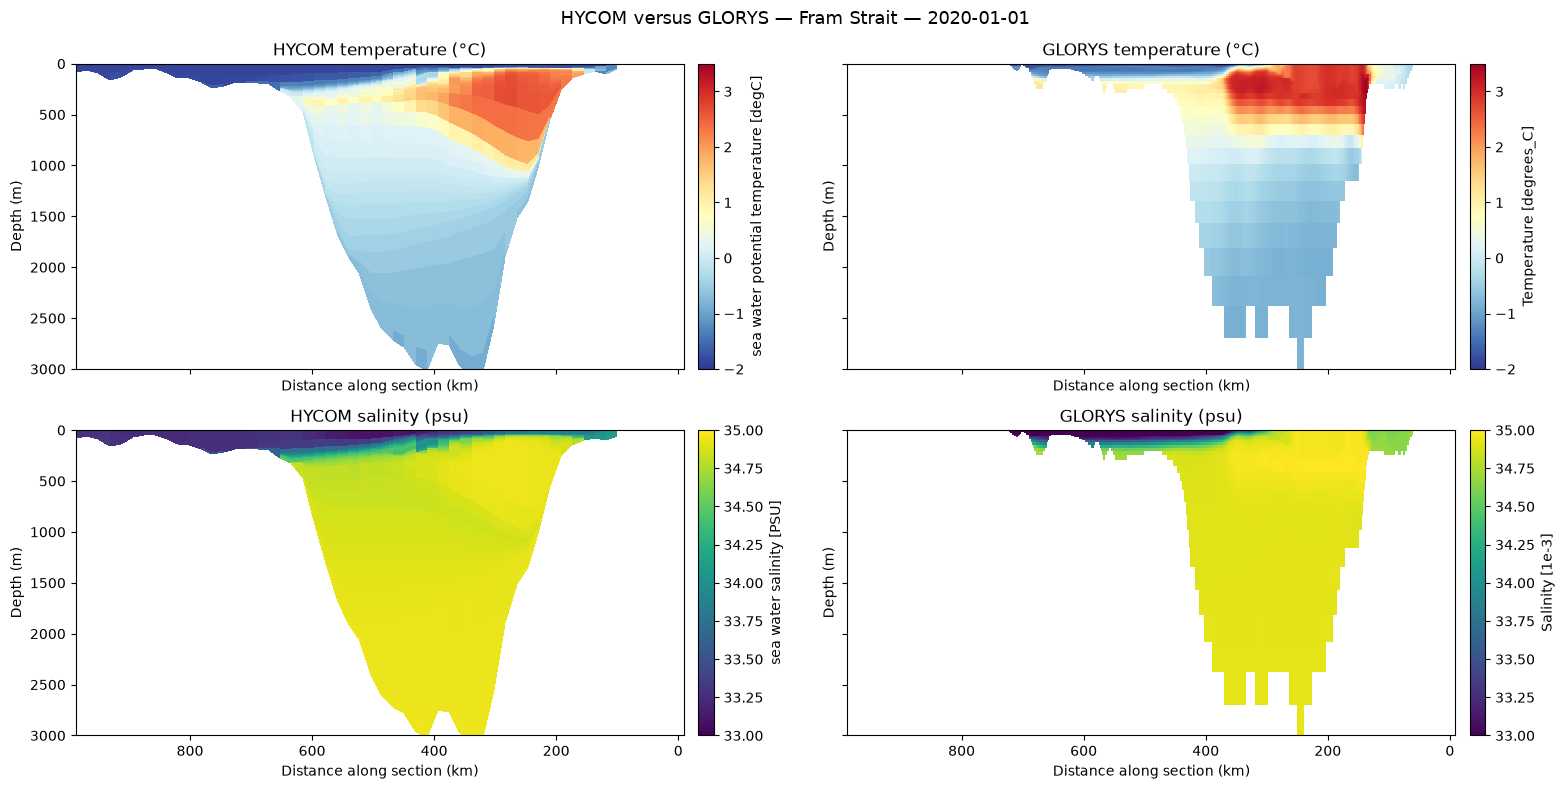

In [15]:
fig = plot_hycom_vs_glorys(sec0_hycom, glorys_sec0)

For GLORYS transport, pass `z_dim`, `u_var`, `v_var`, `t_var`, and `s_var` — this triggers the T-point projection path: `uo`/`vo` (geographic east/north) are projected onto the section normal using the local bearing, then integrated over depth-coordinate spacing. The section spans ~115 cells at 0.083° vs 57 HYCOM cells, so the two transports are evaluated at slightly different geographic locations, but the resulting scalar transport is directly comparable.


In [16]:
%time tr_glorys = xhycom.transport(glorys_data, fs_on_glorys, z_dim="depth", u_var="uo", v_var="vo", t_var="thetao", s_var="so").compute()

CPU times: user 15min 54s, sys: 13min 3s, total: 28min 58s
Wall time: 9min 40s


In [17]:
tr_glorys

<xarray.Dataset> Size: 15kB
Dimensions:  (time: 366)
Coordinates:
  * time     (time) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2020-12-31
Data variables:
    volume   (time) float64 3kB 1.54 -2.84 -5.963 ... -5.246 -3.994 -4.813
    heat     (time) float64 3kB 35.89 40.7 49.42 57.32 ... 90.58 72.55 54.17
    salt     (time) float64 3kB 5.699e+07 -1.007e+08 ... -1.411e+08 -1.704e+08
    fw       (time) float64 3kB -0.05732 -0.01798 -0.03228 ... -0.03714 -0.03542

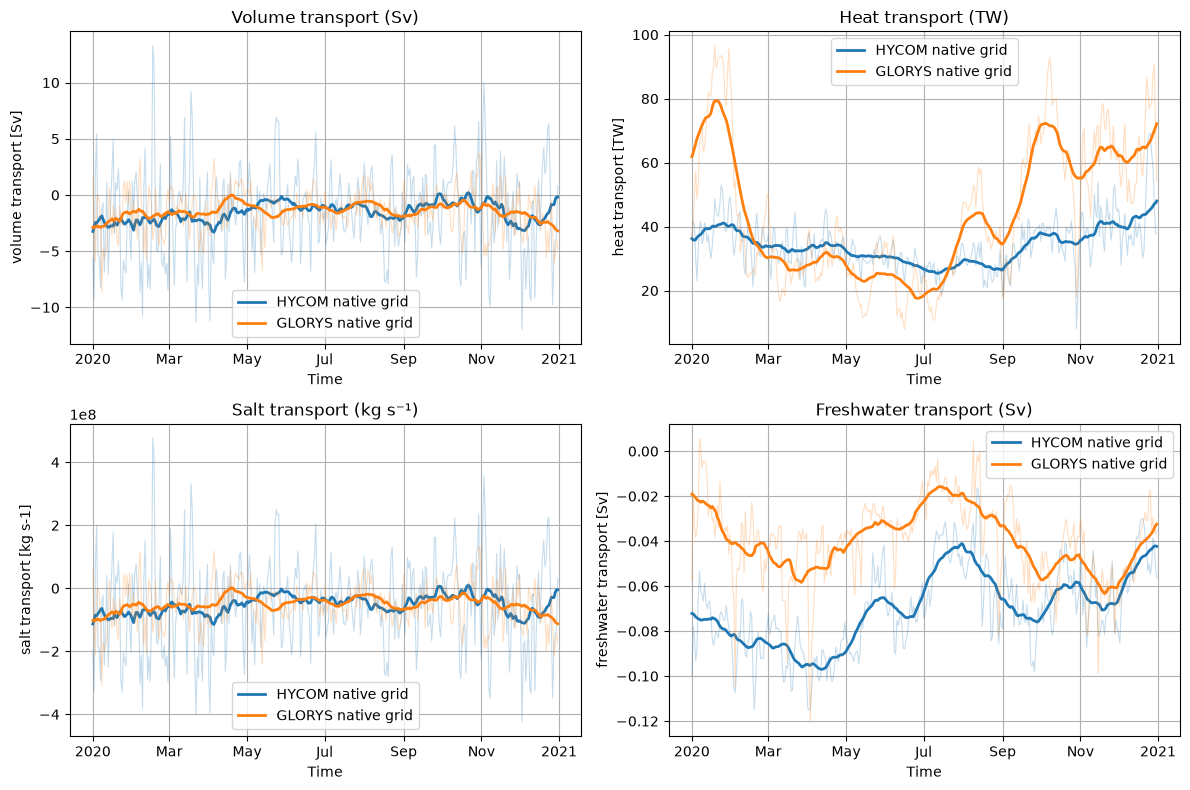

In [18]:
fig = plot_transport_comparison(
    {
        "HYCOM native grid": tr_hycom,
        "GLORYS native grid": tr_glorys
    }
)

Transport *differences* are valid even without regridding: transport is an integrated scalar (Sv, TW, …) with no remaining grid dependence once summed across all section faces and depth levels.

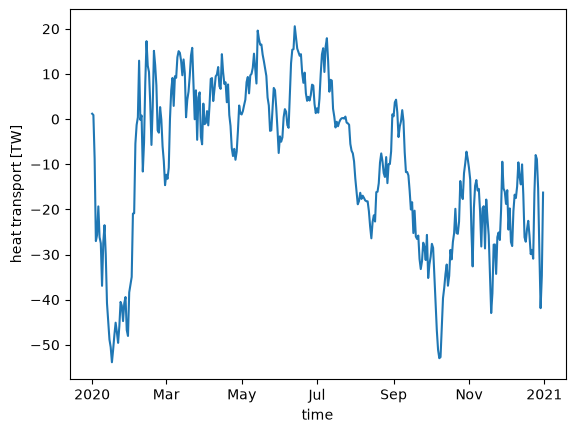

In [29]:
(tr_hycom.heat - tr_glorys.heat).plot()

## Method 2 — Hybrid grid

Two targeted regrids onto a shared grid (HYCOM curvilinear × GLORYS depth levels):

- GLORYS is regridded **horizontally** onto the HYCOM `(y, x)` grid (`regrid_to_hycom`); depth levels stay as GLORYS standard levels.
- HYCOM is regridded **vertically** onto GLORYS depth levels (`regrid_vertical`); the curvilinear horizontal grid is unchanged.

Both datasets end up on the same `(y, x, depth)` grid, so cell-by-cell differences are valid.


In [20]:
glorys_on_horizontal_hycom = xhycom.regrid_to_hycom(glorys_data, GRID_PATH, like=ds)

In [21]:
ds_on_glorys_depth = xhycom.regrid_vertical(ds, glorys_data.depth.values)

In [22]:
%%time

sec0_hycom_m2  = xhycom.section_data(ds_on_glorys_depth.isel(time=0), fs_on_hycom, variables=["temp",   "salin"], z_dim="depth").compute()
sec0_glorys_m2 = xhycom.section_data(glorys_on_horizontal_hycom.isel(time=0),    fs_on_hycom, variables=["thetao",  "so"  ], z_dim="depth").compute()

CPU times: user 5.2 s, sys: 3.3 s, total: 8.49 s
Wall time: 3.73 s


With both datasets on the same grid, a cell-by-cell difference plot is valid.


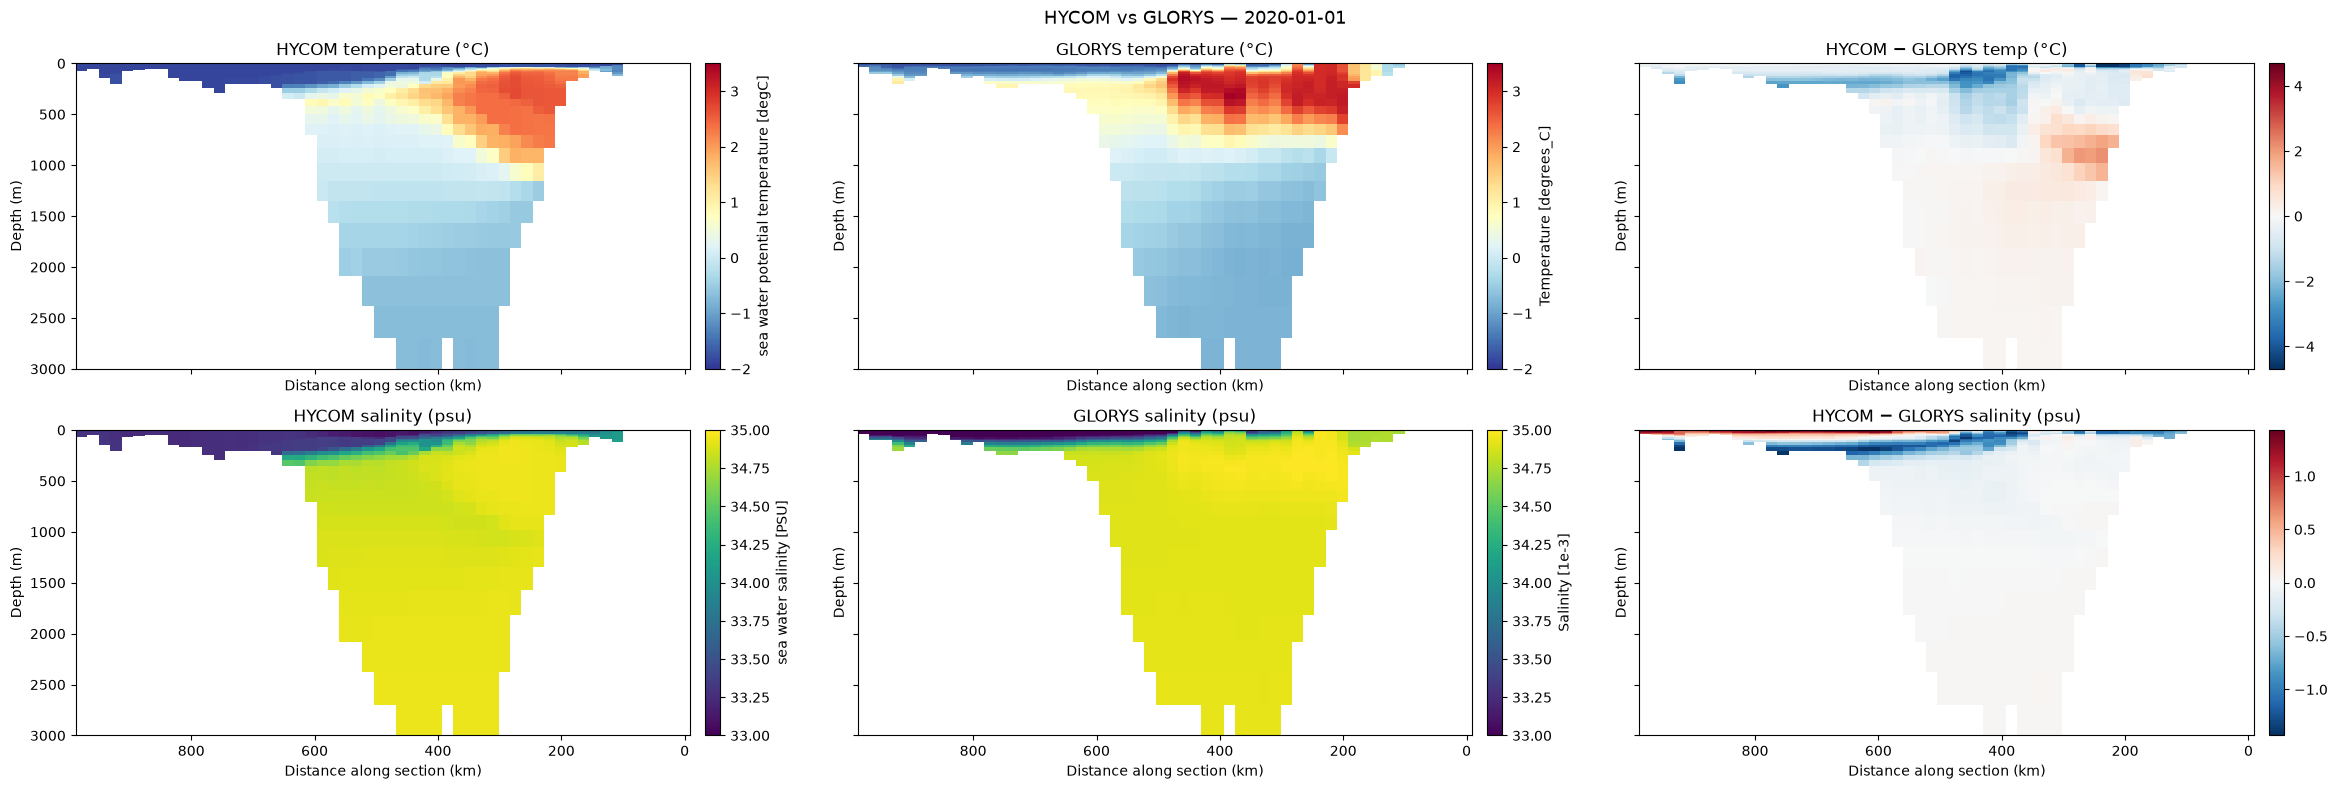

In [23]:
fig = plot_hycom_vs_glorys(
    sec0_hycom_m2,
    sec0_glorys_m2,
    show_diff=True,
    title=f"HYCOM vs GLORYS — {str(ds.time.values[0])[:10]}",
)

Daily HYCOM transports across Fram Strait for 2020.


In [24]:
%time tr_hycom_m3 = xhycom.transport(ds_on_glorys_depth, fs_on_hycom, z_dim="depth").compute()

CPU times: user 9min 22s, sys: 2min 43s, total: 12min 5s
Wall time: 2min 45s


In [25]:
# Convert cftime → datetime64 for joint plotting with GLORYS
tr_hycom_m3 = tr_hycom_m3.assign_coords(time=tr_hycom_m3.indexes["time"].to_datetimeindex(time_unit="ns"))

Daily GLORYS transports across Fram Strait for 2020.


In [26]:
%time tr_glorys_m3 = xhycom.transport(glorys_on_horizontal_hycom, fs_on_hycom, z_dim="depth", u_var="uo", v_var="vo", t_var="thetao", s_var="so").compute()

CPU times: user 44min 41s, sys: 30min 36s, total: 1h 15min 18s
Wall time: 12min 49s


Compute times for Method 2 are comparable to Method 1, with a small overhead for the regridding step.


## Comparing transports across methods

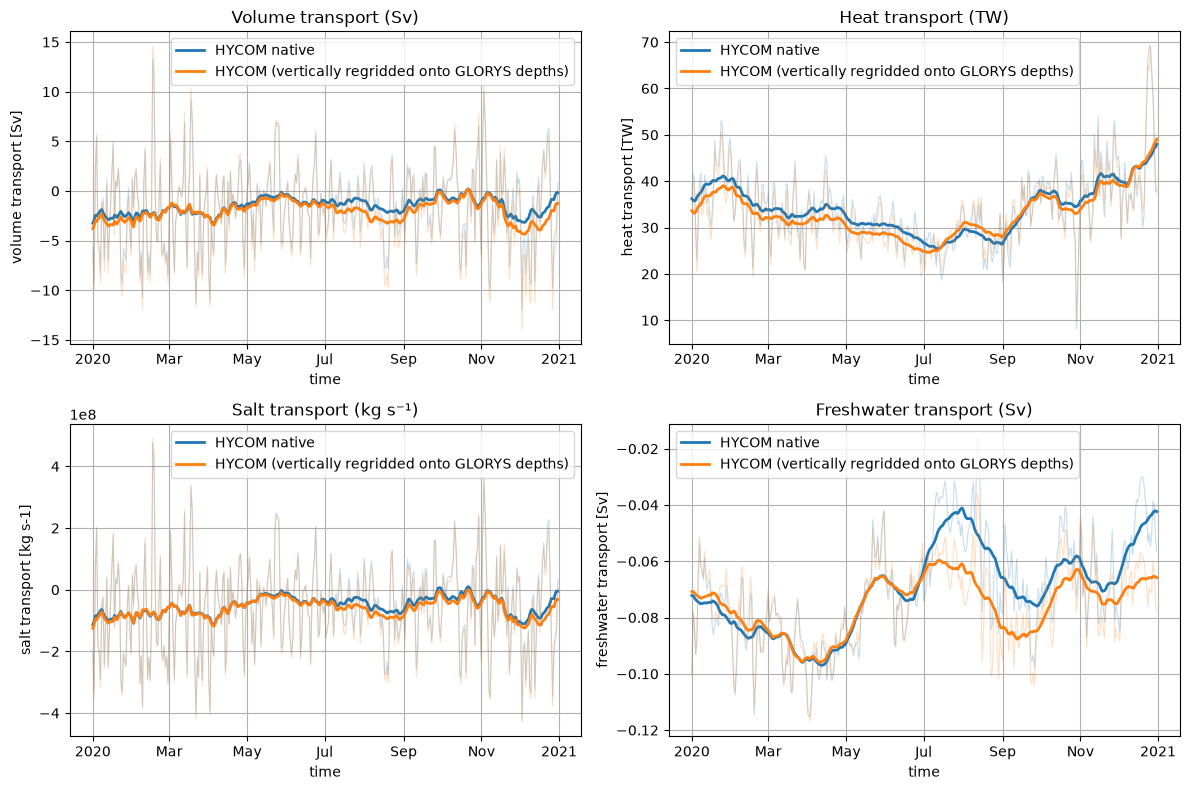

In [27]:
fig = plot_transport_comparison({
    "HYCOM native":          tr_hycom,
    "HYCOM (vertically regridded onto GLORYS depths)":  tr_hycom_m3,
})

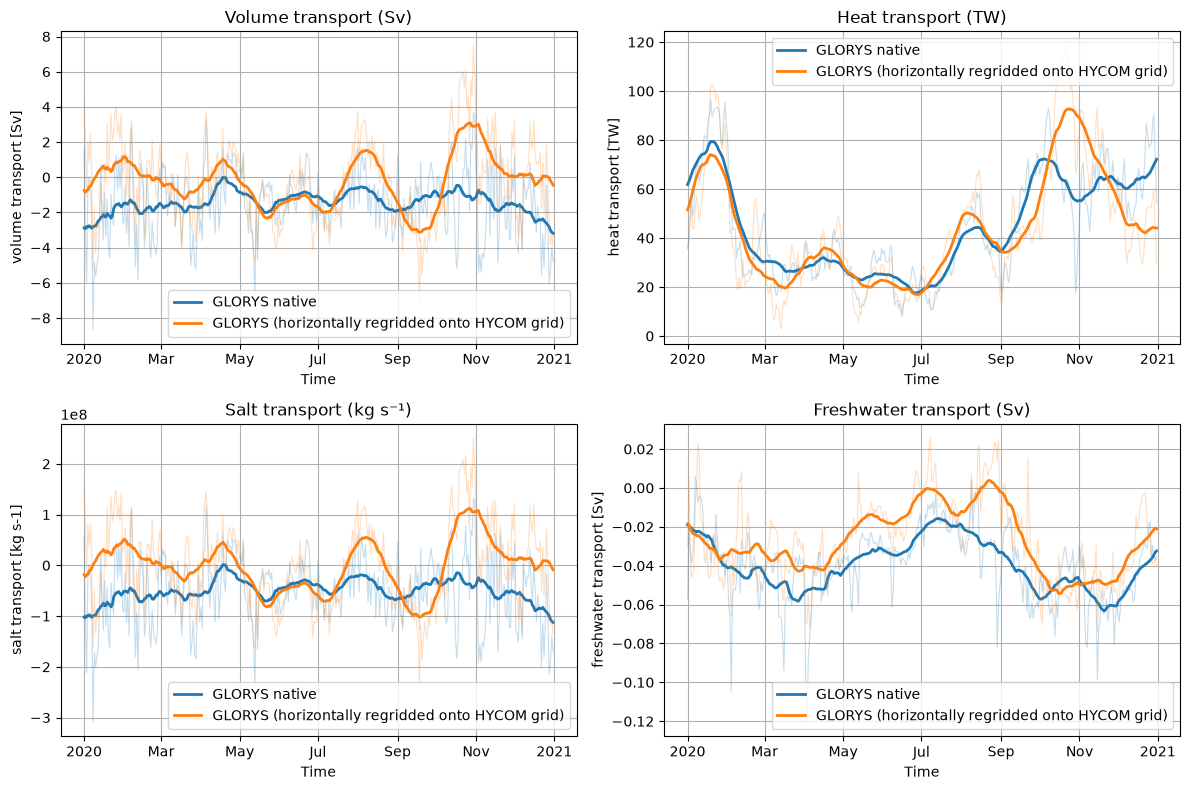

In [28]:
fig = plot_transport_comparison({
    "GLORYS native":          tr_glorys,
    "GLORYS (horizontally regridded onto HYCOM grid)":    tr_glorys_m3,
})

The transport estimates differ substantially across methods. Most notably, GLORYS transport computed on the coarser HYCOM horizontal grid is a poor approximation of the native-grid result.

**Takeaways:**
- Compute transports on the native grid (HYCOM on HYCOM, GLORYS on GLORYS).
- Use Method 2 when co-registered section plots and valid difference maps are needed.
